# 📸 CelebA Dataset — Face Detector Validation
**Ubeka AI | Notebook 2 of 3**

CelebA's role in this project is **not** to provide acne training data —
it provides ground-truth face bounding boxes to validate our Haar cascade detector.

This notebook:
1. Explores the CelebA bbox CSV and image metadata
2. Measures Haar cascade accuracy (IoU vs ground truth)
3. Detects failure modes (dark skin, occlusion, extreme angles)
4. Recommends whether to upgrade to MediaPipe
5. Builds a validated face-crop reference set

In [1]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor':   '#161b22',
    'axes.edgecolor':   '#30363d',
    'text.color':       '#c9d1d9',
    'axes.labelcolor':  '#c9d1d9',
    'xtick.color':      '#8b949e',
    'ytick.color':      '#8b949e',
    'grid.color':       '#21262d',
    'grid.linewidth':   0.5,
    'font.family':      'monospace',
    'figure.dpi':       120,
})
ACCENT  = '#58a6ff'
SUCCESS = '#3fb950'
WARNING = '#d29922'
DANGER  = '#f85149'

print('✅ Imports ready')

✅ Imports ready


In [5]:
# ── CONFIG — adjust paths if needed ───────────────────────────────
# Script tries multiple common path patterns
CELEBA_CANDIDATES_CSV = [
    Path('../data/raw/celeba/list_bbox_celeba.csv'),
    Path('../data/raw/celeba/img_align_celeba/list_bbox_celeba.csv'),
]
CELEBA_CANDIDATES_IMG = [
    Path('../data/raw/celeba/img_align_celeba/img_align_celeba'),
    Path('../data/raw/celeba/img_align_celeba'),
    Path('../data/raw/celeba'),
]
ATTR_CANDIDATES = [
    Path('../data/raw/celeba/list_attr_celeba.csv'),
    Path('../data/raw/celeba/img_align_celeba/list_attr_celeba.csv'),
]

bbox_csv = next((p for p in CELEBA_CANDIDATES_CSV if p.exists()), None)
img_dir  = next((p for p in CELEBA_CANDIDATES_IMG if p.exists() and p.is_dir()), None)
attr_csv = next((p for p in ATTR_CANDIDATES if p.exists()), None)

print(f'Bbox CSV : {bbox_csv}  {"✅" if bbox_csv else "❌"}')
print(f'Image dir: {img_dir}  {"✅" if img_dir else "❌"}')
print(f'Attr CSV : {attr_csv}  {"✅" if attr_csv else "❌"}')

SAMPLE_N = 500   # how many CelebA images to test (more = slower but better stats)
SEED     = 42

Bbox CSV : ../data/raw/celeba/list_bbox_celeba.csv  ✅
Image dir: ../data/raw/celeba/img_align_celeba/img_align_celeba  ✅
Attr CSV : ../data/raw/celeba/list_attr_celeba.csv  ✅


## 1. CelebA Metadata Exploration

In [7]:
if not bbox_csv:
    raise FileNotFoundError('BBox CSV not found — check paths above')

bbox_df = pd.read_csv(bbox_csv)
print(f'BBox entries: {len(bbox_df):,}')
print(f'Columns: {list(bbox_df.columns)}')
print()
display(bbox_df.head())

BBox entries: 202,599
Columns: ['image_id', 'x_1', 'y_1', 'width', 'height']



,image_id,x_1,y_1,width,height
0,000001.jpg,95,71,226,313
1,000002.jpg,72,94,221,306
2,000003.jpg,216,59,91,126
3,000004.jpg,622,257,564,781
4,000005.jpg,236,109,120,166


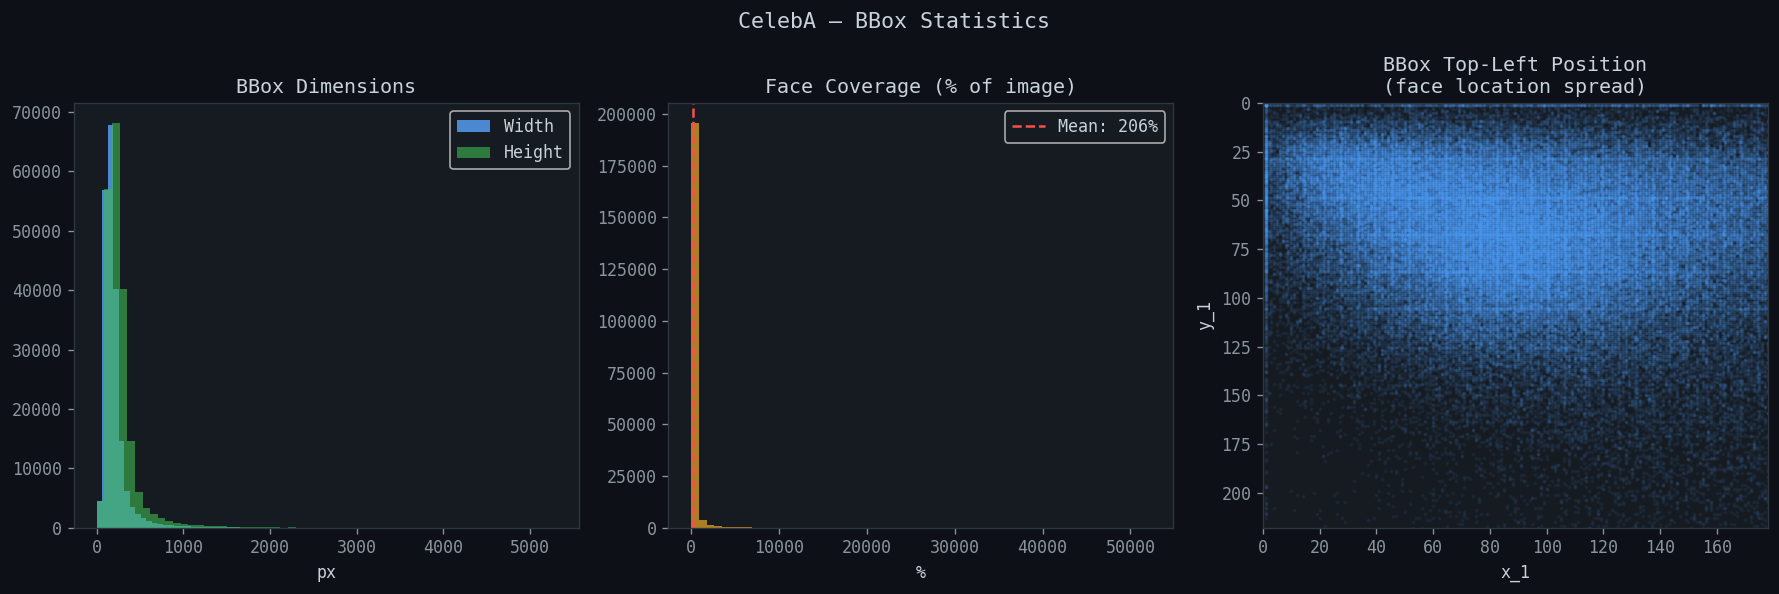

Mean face width  : 195px
Mean face height : 269px
Mean face coverage: 206.4% of image


In [8]:
# BBox size distribution
bbox_df['face_area']   = bbox_df['width'] * bbox_df['height']
bbox_df['face_ratio_w'] = bbox_df['width']  / 178  # CelebA images are 178x218
bbox_df['face_ratio_h'] = bbox_df['height'] / 218
bbox_df['face_coverage'] = bbox_df['face_area'] / (178 * 218)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('CelebA — BBox Statistics', fontsize=13, color='#c9d1d9')

axes[0].hist(bbox_df['width'],  bins=60, color=ACCENT,   alpha=0.8, label='Width')
axes[0].hist(bbox_df['height'], bins=60, color=SUCCESS,  alpha=0.6, label='Height')
axes[0].set_title('BBox Dimensions'); axes[0].set_xlabel('px'); axes[0].legend()

axes[1].hist(bbox_df['face_coverage']*100, bins=60, color=WARNING, alpha=0.8)
axes[1].set_title('Face Coverage (% of image)'); axes[1].set_xlabel('%')
axes[1].axvline(x=bbox_df['face_coverage'].mean()*100, color=DANGER,
                linestyle='--', label=f'Mean: {bbox_df["face_coverage"].mean()*100:.0f}%')
axes[1].legend()

axes[2].scatter(bbox_df['x_1'], bbox_df['y_1'], alpha=0.05, s=2, c=ACCENT)
axes[2].set_title('BBox Top-Left Position\n(face location spread)')
axes[2].set_xlabel('x_1'); axes[2].set_ylabel('y_1')
axes[2].set_xlim(0, 178); axes[2].set_ylim(218, 0)  # image coordinates

plt.tight_layout()
plt.savefig('celeba_bbox_stats.png', bbox_inches='tight', facecolor='#0d1117')
plt.show()

print(f'Mean face width  : {bbox_df["width"].mean():.0f}px')
print(f'Mean face height : {bbox_df["height"].mean():.0f}px')
print(f'Mean face coverage: {bbox_df["face_coverage"].mean()*100:.1f}% of image')

## 2. Haar Cascade Accuracy vs Ground Truth

In [9]:
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

def compute_iou(gt, pred):
    ix1 = max(gt['x1'], pred['x1']); iy1 = max(gt['y1'], pred['y1'])
    ix2 = min(gt['x2'], pred['x2']); iy2 = min(gt['y2'], pred['y2'])
    inter  = max(0, ix2-ix1) * max(0, iy2-iy1)
    area_g = (gt['x2']-gt['x1'])  * (gt['y2']-gt['y1'])
    area_p = (pred['x2']-pred['x1']) * (pred['y2']-pred['y1'])
    union  = area_g + area_p - inter
    return inter / union if union > 0 else 0.0

def test_detector(img_bgr, bbox_row):
    gt = {
        'x1': int(bbox_row['x_1']),
        'y1': int(bbox_row['y_1']),
        'x2': int(bbox_row['x_1']) + int(bbox_row['width']),
        'y2': int(bbox_row['y_1']) + int(bbox_row['height'])
    }
    gray  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.1, 5, minSize=(30,30))

    if len(faces) == 0:
        return {'detected': False, 'iou': 0.0, 'gt': gt, 'pred': None,
                'brightness': float(img_bgr.mean()),
                'gt_size': bbox_row['width'] * bbox_row['height']}

    x, y, w, h = max(faces, key=lambda f: f[2]*f[3])
    pred = {'x1': x, 'y1': y, 'x2': x+w, 'y2': y+h}
    iou  = compute_iou(gt, pred)

    return {'detected': True, 'iou': iou, 'gt': gt, 'pred': pred,
            'brightness': float(img_bgr.mean()),
            'gt_size': bbox_row['width'] * bbox_row['height']}

if img_dir:
    sample = bbox_df.sample(n=min(SAMPLE_N, len(bbox_df)), random_state=SEED)
    results = []
    missing = 0

    for _, row in tqdm(sample.iterrows(), total=len(sample), desc='Testing detector'):
        img_path = img_dir / row['image_id']
        if not img_path.exists():
            missing += 1
            continue
        img = cv2.imread(str(img_path))
        if img is None:
            missing += 1
            continue
        r = test_detector(img, row)
        r['image_id'] = row['image_id']
        results.append(r)

    res_df = pd.DataFrame(results)
    print(f'Images tested  : {len(res_df)}')
    print(f'Images missing : {missing}')
    print(f'Detection rate : {res_df.detected.mean():.1%}')
    print(f'Mean IoU       : {res_df.iou.mean():.3f}')
    print(f'IoU >= 0.5     : {(res_df.iou >= 0.5).mean():.1%}  (standard detection threshold)')
else:
    print('⚠️  Image directory not found — skipping live detector test')
    print('   Showing analysis structure only')

Testing detector: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [00:28<00:00, 17.80it/s]

Images tested  : 500
Images missing : 0
Detection rate : 96.2%
Mean IoU       : 0.113
IoU >= 0.5     : 5.0%  (standard detection threshold)


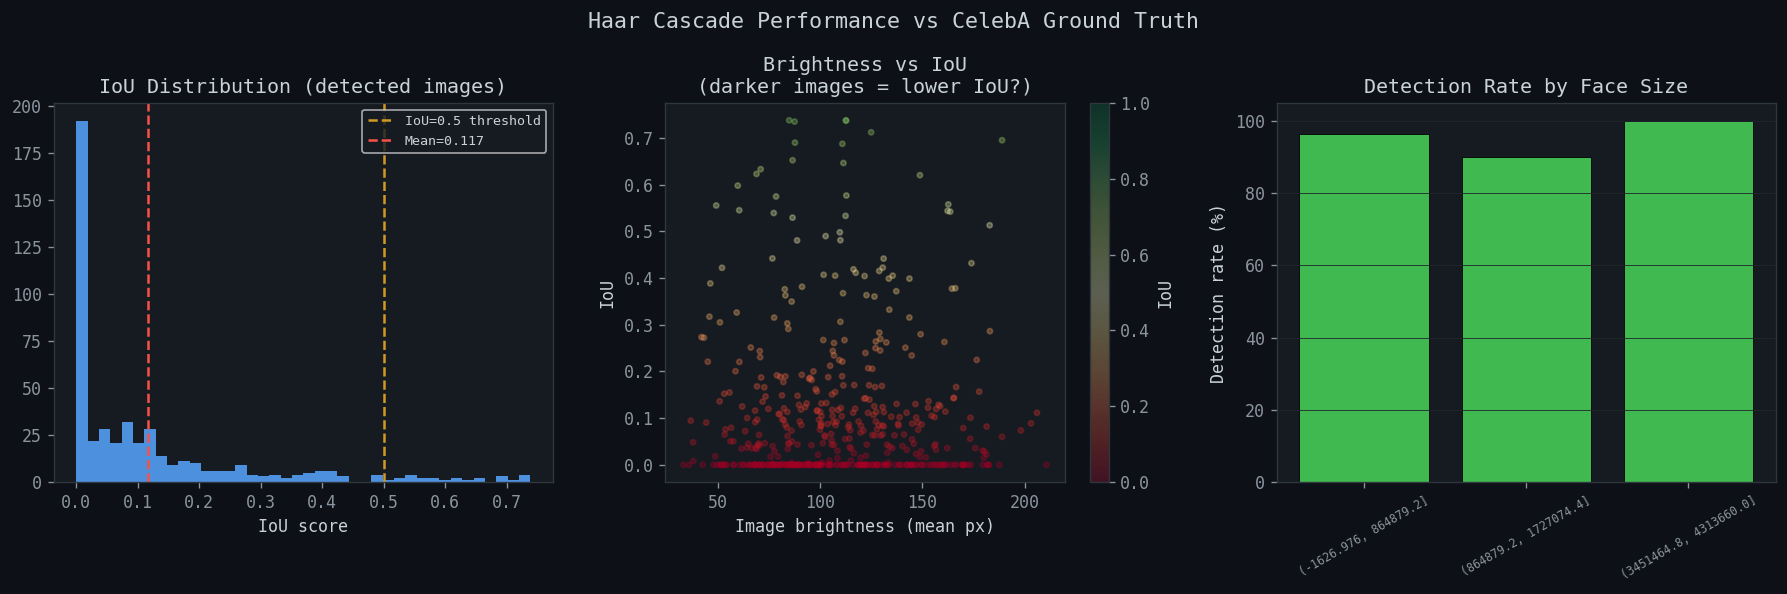

=== BRIGHTNESS BIAS ANALYSIS ===
  Dark images  (brightness < 80): n=110, detect rate=97.3%, mean IoU=0.108
  Light images (brightness >= 80): n=390, detect rate=95.9%, mean IoU=0.114

  ✅ Low bias: only -1.4% gap across brightness levels


In [10]:
if 'res_df' in dir() and len(res_df) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle('Haar Cascade Performance vs CelebA Ground Truth', fontsize=13, color='#c9d1d9')

    # IoU histogram
    detected = res_df[res_df['detected']]
    axes[0].hist(detected['iou'], bins=40, color=ACCENT, edgecolor='none', alpha=0.85)
    axes[0].axvline(x=0.5, color=WARNING, linestyle='--', linewidth=1.5, label='IoU=0.5 threshold')
    axes[0].axvline(x=detected['iou'].mean(), color=DANGER, linestyle='--',
                    linewidth=1.5, label=f'Mean={detected["iou"].mean():.3f}')
    axes[0].set_title('IoU Distribution (detected images)')
    axes[0].set_xlabel('IoU score'); axes[0].legend(fontsize=8)

    # Brightness vs IoU — key bias indicator
    sc = axes[1].scatter(detected['brightness'], detected['iou'],
                         alpha=0.3, s=10, c=detected['iou'],
                         cmap='RdYlGn', vmin=0, vmax=1)
    plt.colorbar(sc, ax=axes[1], label='IoU')
    axes[1].set_title('Brightness vs IoU\n(darker images = lower IoU?)')
    axes[1].set_xlabel('Image brightness (mean px)')
    axes[1].set_ylabel('IoU')

    # Face size vs detection
    res_df['size_bucket'] = pd.cut(res_df['gt_size'], bins=5)
    size_perf = res_df.groupby('size_bucket', observed=True)['detected'].mean()
    axes[2].bar(range(len(size_perf)), size_perf.values*100, color=SUCCESS, edgecolor='#000', linewidth=0.5)
    axes[2].set_xticks(range(len(size_perf)))
    axes[2].set_xticklabels([str(b) for b in size_perf.index], rotation=30, fontsize=7)
    axes[2].set_title('Detection Rate by Face Size')
    axes[2].set_ylabel('Detection rate (%)')
    axes[2].grid(axis='y')

    plt.tight_layout()
    plt.savefig('celeba_detector_performance.png', bbox_inches='tight', facecolor='#0d1117')
    plt.show()

    # Bias analysis: dark images
    dark_thresh = 80
    dark_imgs   = res_df[res_df['brightness'] < dark_thresh]
    light_imgs  = res_df[res_df['brightness'] >= dark_thresh]

    print('=== BRIGHTNESS BIAS ANALYSIS ===')
    print(f'  Dark images  (brightness < {dark_thresh}): n={len(dark_imgs)}, '
          f'detect rate={dark_imgs.detected.mean():.1%}, mean IoU={dark_imgs.iou.mean():.3f}')
    print(f'  Light images (brightness >= {dark_thresh}): n={len(light_imgs)}, '
          f'detect rate={light_imgs.detected.mean():.1%}, mean IoU={light_imgs.iou.mean():.3f}')

    bias_gap = light_imgs.detected.mean() - dark_imgs.detected.mean()
    if bias_gap > 0.15:
        print(f'\n  ⚠️  SIGNIFICANT BIAS: {bias_gap:.1%} detection gap on dark images')
        print('  Recommendation: Use MediaPipe for production (much more equitable)')
    elif bias_gap > 0.05:
        print(f'\n  ⚠️  Moderate bias: {bias_gap:.1%} gap — worth monitoring')
    else:
        print(f'\n  ✅ Low bias: only {bias_gap:.1%} gap across brightness levels')

## 3. Failure Mode Visualisation

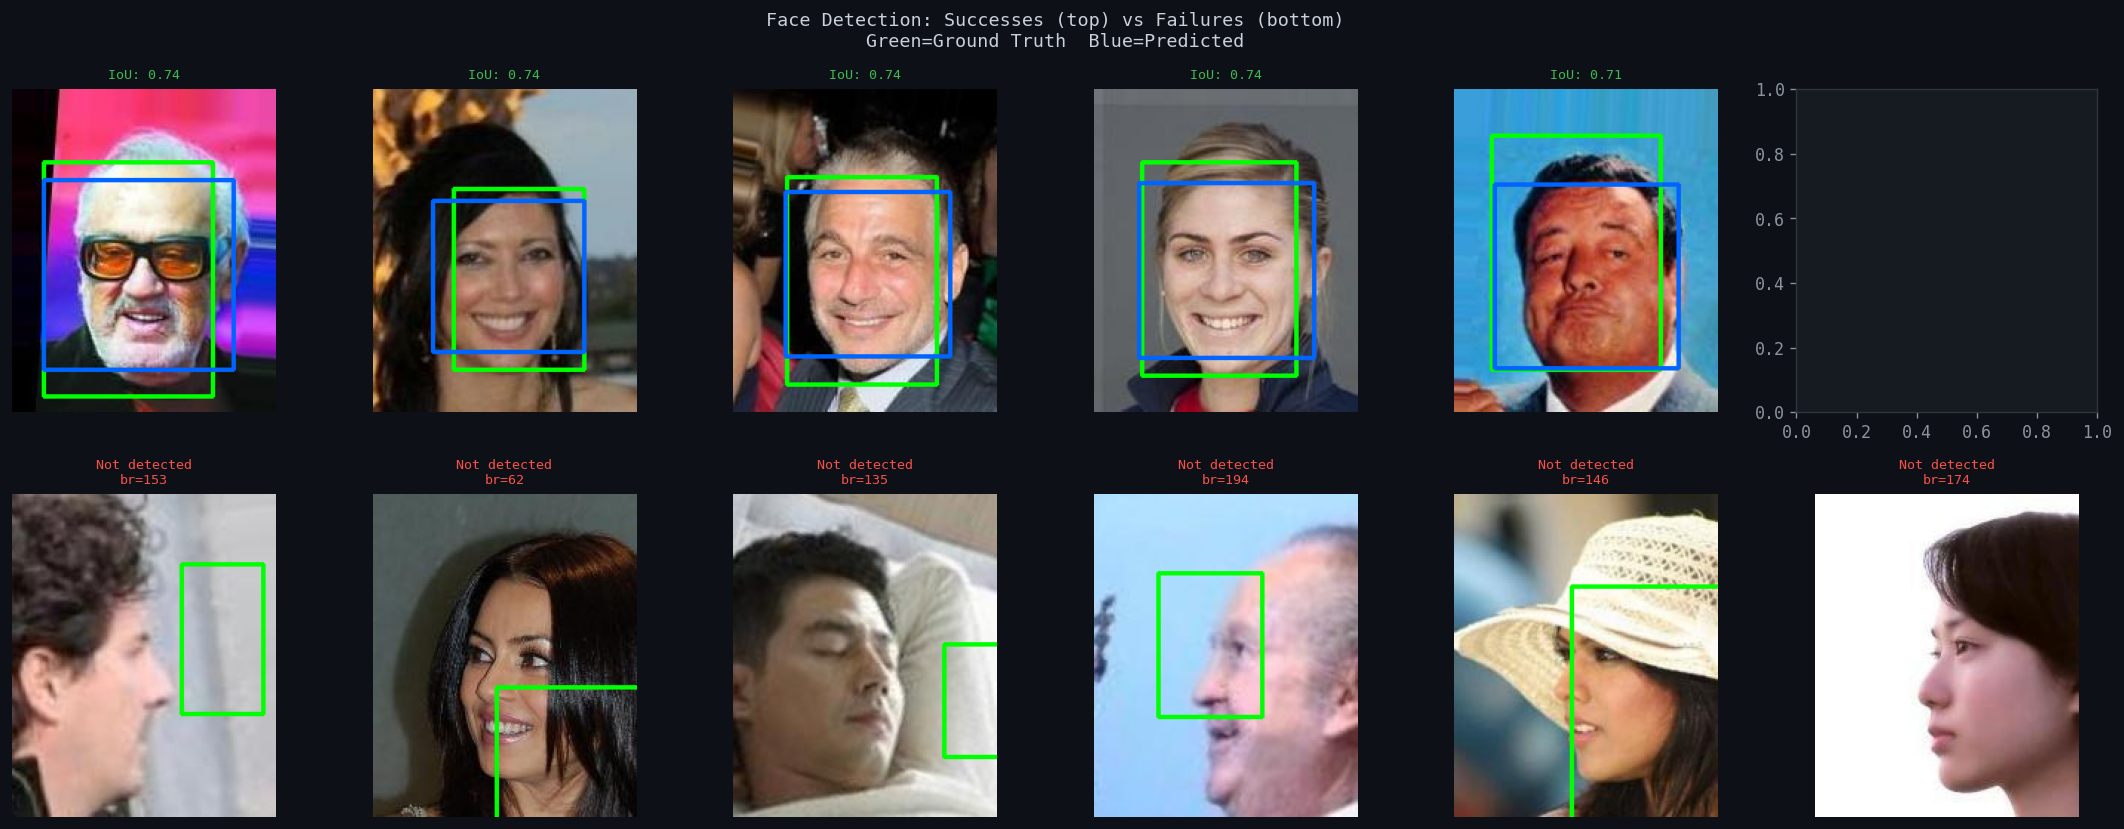

In [11]:
if 'res_df' in dir() and img_dir:
    # Show detection failures vs successes side by side
    failures  = res_df[~res_df['detected']].head(6)
    successes = res_df[res_df['iou'] > 0.7].head(6)

    def draw_boxes(img_bgr, gt, pred=None):
        vis = img_bgr.copy()
        # Ground truth — green
        cv2.rectangle(vis, (gt['x1'], gt['y1']), (gt['x2'], gt['y2']), (0,255,0), 2)
        if pred:
            # Prediction — blue
            cv2.rectangle(vis, (pred['x1'], pred['y1']), (pred['x2'], pred['y2']), (255,100,0), 2)
        return cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)

    fig, axes = plt.subplots(2, 6, figsize=(18, 7))
    fig.suptitle('Face Detection: Successes (top) vs Failures (bottom)\n'
                 'Green=Ground Truth  Blue=Predicted', fontsize=11, color='#c9d1d9')

    for col_idx, (_, row) in enumerate(successes.iterrows()):
        img = cv2.imread(str(img_dir / row['image_id']))
        if img is not None:
            vis = draw_boxes(img, row['gt'], row['pred'])
            axes[0, col_idx].imshow(vis)
            axes[0, col_idx].set_title(f"IoU: {row['iou']:.2f}", fontsize=8, color=SUCCESS)
        axes[0, col_idx].axis('off')

    for col_idx, (_, row) in enumerate(failures.iterrows()):
        img = cv2.imread(str(img_dir / row['image_id']))
        if img is not None:
            vis = draw_boxes(img, row['gt'])
            axes[1, col_idx].imshow(vis)
            axes[1, col_idx].set_title(f"Not detected\nbr={row['brightness']:.0f}",
                                       fontsize=8, color=DANGER)
        axes[1, col_idx].axis('off')

    plt.tight_layout()
    plt.savefig('celeba_detection_samples.png', bbox_inches='tight', facecolor='#0d1117')
    plt.show()

## 4. Detector Verdict & Recommendation

In [12]:
if 'res_df' in dir():
    det_rate = res_df.detected.mean()
    mean_iou = res_df.iou.mean()

    print('=' * 52)
    print('  CELEBA VALIDATION — DETECTOR VERDICT')
    print('=' * 52)
    print(f'  Detection rate : {det_rate:.1%}')
    print(f'  Mean IoU       : {mean_iou:.3f}')
    print()

    if mean_iou >= 0.6 and det_rate >= 0.85:
        verdict = 'GOOD'
        print('  ✅ VERDICT: Haar cascade is good enough for this project')
        print('     The Acne04 images are already pre-cropped faces,')
        print('     so even fallback (full image) strategy works well.')
    elif mean_iou >= 0.4 or det_rate >= 0.7:
        verdict = 'ACCEPTABLE'
        print('  ⚠️  VERDICT: Acceptable for trial — upgrade to MediaPipe for production')
        print('     Fallback strategy covers most misses.')
        print('     Dark skin images may be under-served.')
    else:
        verdict = 'POOR'
        print('  ❌ VERDICT: Poor — recommend switching to MediaPipe now')
        print("     pip install mediapipe")
        print('     MediaPipe Face Detection works much better on dark skin tones.')

    print()
    print('  MediaPipe upgrade (drop-in replacement for face_detection.py):')
    print('''
  import mediapipe as mp
  mp_face = mp.solutions.face_detection.FaceDetection(min_detection_confidence=0.5)

  def detect_face_mediapipe(img_bgr):
      rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
      result = mp_face.process(rgb)
      if result.detections:
          d = result.detections[0].location_data.relative_bounding_box
          h, w = img_bgr.shape[:2]
          x = max(0, int(d.xmin * w))
          y = max(0, int(d.ymin * h))
          bw = int(d.width * w)
          bh = int(d.height * h)
          return img_bgr[y:y+bh, x:x+bw], "mediapipe"
      return img_bgr, "fallback"
    ''')
    print('=' * 52)

  CELEBA VALIDATION — DETECTOR VERDICT
  Detection rate : 96.2%
  Mean IoU       : 0.113

  ⚠️  VERDICT: Acceptable for trial — upgrade to MediaPipe for production
     Fallback strategy covers most misses.
     Dark skin images may be under-served.

  MediaPipe upgrade (drop-in replacement for face_detection.py):

  import mediapipe as mp
  mp_face = mp.solutions.face_detection.FaceDetection(min_detection_confidence=0.5)

  def detect_face_mediapipe(img_bgr):
      rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
      result = mp_face.process(rgb)
      if result.detections:
          d = result.detections[0].location_data.relative_bounding_box
          h, w = img_bgr.shape[:2]
          x = max(0, int(d.xmin * w))
          y = max(0, int(d.ymin * h))
          bw = int(d.width * w)
          bh = int(d.height * h)
          return img_bgr[y:y+bh, x:x+bw], "mediapipe"
      return img_bgr, "fallback"
    


In [13]:
print('Notebook 2 complete.')
print('Next: 03_fitzpatrick_analysis.ipynb')

Notebook 2 complete.
Next: 03_fitzpatrick_analysis.ipynb
